# 🧬 MAb Off-Target AF3 Matrix-Based Scoring Pipeline
**10 mAb × 24 off-target → 240 summary_confidences.json + Prodigy affinity merge**

In [1]:
# ─── Cell 1: Imports ───────────────────────────────────────────────────────────
import os, json, re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from pathlib import Path

warnings.filterwarnings('ignore')
print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# ─── Cell 2: Configuration ─────────────────────────────────────────────────────
CONFIG = {
    # Root that contains  <mab>_offtarget_af3_output/  subdirs
    "root_dir": "/home/ozangocmen/RFantibody/mab_OTR/mab_offtarget_folders/af3_outputs",

    # Prodigy TSV:  Structure\tAffinity_kcal-mol
    "affinity_file": "/home/ozangocmen/RFantibody/mab_OTR/mab_offtarget_folders/binding_affinity_mab/mab_prodigy.tsv",

    # Output
    "output_csv": "/home/ozangocmen/RFantibody/mab_OTR/mab_offtarget_folders/results/mab_offtarget_scores.csv",

    # Scoring weights  (must sum to 1.0)
    "weights": {
        "w_Matrix_iPTM" : 0.40,
        "w_Matrix_PAE"  : 0.25,
        "w_Affinity"    : 0.25,
        "w_Global_pTM"  : 0.10,
    },

    # Sigmoid for affinity normalisation
    "sigmoid_midpoint" : -9.0,
    "sigmoid_steepness":  1.0,

    # PAE normalisation range  [worst, best]  kcal/mol
    "pae_worst": 12.0,
    "pae_best" :  5.0,

    # Disorder penalty threshold
    "disorder_threshold": 0.15,
}

assert abs(sum(CONFIG['weights'].values()) - 1.0) < 1e-9, "Weights must sum to 1.0"
print('✅ Config OK — weights sum to', round(sum(CONFIG['weights'].values()), 4))

✅ Config OK — weights sum to 1.0


In [3]:
# ─── Cell 3: Helper Functions ──────────────────────────────────────────────────

def parse_summary_json(json_path: str) -> dict | None:
    """Extract matrix metrics from an AF3 summary_confidences.json."""
    try:
        with open(json_path) as f:
            d = json.load(f)

        # ── Matrix iPTM: average of off-diagonal chain-pair values ──────────
        cp_iptm = d.get('chain_pair_iptm', [])
        if cp_iptm and len(cp_iptm) >= 3:
            # [0][2] and [1][2] are the two cross-chain entries (A↔C, B↔C)
            interaction_iptm = (cp_iptm[0][2] + cp_iptm[1][2]) / 2.0
        else:
            interaction_iptm = d.get('iptm', 0.0)

        # ── Matrix PAE: best interface PAE ──────────────────────────────────
        cp_pae = d.get('chain_pair_pae_min', [])
        if cp_pae and len(cp_pae) >= 3:
            interface_pae = min(cp_pae[0][2], cp_pae[1][2])
        else:
            interface_pae = 15.0          # penalising fallback

        return {
            'pTM'               : d.get('ptm', 0.0),
            'Has_Clash'         : int(d.get('has_clash', 0)),
            'Fraction_Disordered': d.get('fraction_disordered', 0.0),
            'Ranking_Score'     : d.get('ranking_score', 0.0),
            'Matrix_iPTM'       : interaction_iptm,
            'Matrix_PAE'        : interface_pae,
        }
    except Exception as exc:
        print(f'  ⚠️  JSON parse error → {json_path}\n     {exc}')
        return None


def sigmoid_affinity(dG: float, mid: float, steep: float) -> float:
    """Map ΔG (kcal/mol) to [0, 1]; values > -4 → 0."""
    if dG > -4.0:
        return 0.0
    return 1.0 / (1.0 + np.exp(steep * (dG - mid)))


def scientific_score(row: pd.Series, cfg: dict) -> float:
    """Compute the weighted matrix-based interaction score."""
    w = cfg['weights']

    # Normalise PAE  (higher PAE → lower score)
    norm_pae = np.clip(
        (cfg['pae_worst'] - row['Matrix_PAE']) / (cfg['pae_worst'] - cfg['pae_best']),
        0, 1
    )

    # Affinity term
    aff = sigmoid_affinity(
        row.get('Affinity_dG', 0.0),
        cfg['sigmoid_midpoint'],
        cfg['sigmoid_steepness']
    )

    # Disorder penalty
    frac = row.get('Fraction_Disordered', 0.0)
    penalty = max(0.0, frac - cfg['disorder_threshold'])

    score = (
        w['w_Matrix_iPTM'] * row['Matrix_iPTM'] +
        w['w_Global_pTM']  * row['pTM']         +
        w['w_Matrix_PAE']  * norm_pae            +
        w['w_Affinity']    * aff
    ) - penalty

    # Clash → disqualify
    if row.get('Has_Clash', 0):
        return 0.0

    return float(max(0.0, score))


print('✅ Helper functions defined')

✅ Helper functions defined


In [4]:
# ─── Cell 4: Discover & Parse All summary_confidences.json ────────────────────
#
# Expected tree:
#   root/
#     <mab>_offtarget_af3_output/
#       <mab>_vs_<target>/
#         <mab>_vs_<target>_summary_confidences.json
#

root = Path(CONFIG['root_dir'])
json_files = sorted(root.rglob('*_summary_confidences.json'))

print(f'📁 Root : {root}')
print(f'🔍 Found: {len(json_files)} summary_confidences.json files\n')

records = []
for jf in json_files:
    # Sample_ID = the immediate parent folder name  (e.g. eclutatug_vs_cld6)
    sample_id = jf.parent.name

    metrics = parse_summary_json(str(jf))
    if metrics:
        metrics['Sample_ID'] = sample_id
        metrics['JSON_Path'] = str(jf)
        records.append(metrics)

df = pd.DataFrame(records)
print(f'✅ Successfully parsed: {len(df)} / {len(json_files)} models')
df.head(3)

📁 Root : /home/ozangocmen/RFantibody/mab_OTR/mab_offtarget_folders/af3_outputs
🔍 Found: 250 summary_confidences.json files

✅ Successfully parsed: 250 / 250 models


,pTM,Has_Clash,Fraction_Disordered,Ranking_Score,Matrix_iPTM,Matrix_PAE,Sample_ID,JSON_Path
0,0.60,0,0.05,0.53,0.230,8.79,eclutatug_vs_cld1,/home/ozangocmen/RFantibody/mab_OTR/mab_offtar...
1,0.55,0,0.09,0.50,0.170,11.52,eclutatug_vs_cld10,/home/ozangocmen/RFantibody/mab_OTR/mab_offtar...
2,0.60,0,0.05,0.52,0.225,10.43,eclutatug_vs_cld11,/home/ozangocmen/RFantibody/mab_OTR/mab_offtar...


In [5]:
# ─── Cell 5: Load & Merge Prodigy Affinity ────────────────────────────────────

aff_path = CONFIG['affinity_file']

if not os.path.exists(aff_path):
    print(f'⚠️  Affinity file not found: {aff_path}')
    df['Affinity_dG'] = 0.0
else:
    df_aff = pd.read_csv(aff_path, sep='\t')
    df_aff.columns = df_aff.columns.str.strip()

    # Normalise column names
    df_aff.rename(columns={
        'Affinity_kcal-mol': 'Affinity_dG',
        'dG'               : 'Affinity_dG',
    }, inplace=True)

    df_aff['Affinity_dG'] = (
        df_aff['Affinity_dG'].astype(str).str.strip().astype(float)
    )

    # ── Derive Sample_ID from Structure ──────────────────────────────────────
    # "eclutatug_vs_cld6_model_model0"  →  "eclutatug_vs_cld6"
    df_aff['Sample_ID'] = (
        df_aff['Structure']
        .astype(str).str.strip()
        .str.replace(r'_model.*$', '', regex=True)   # drop _model_model0
        # ── Known naming inconsistency patches ──
        .str.replace('cld182', 'cld18_2', regex=False)
    )

    # Merge
    before = len(df)
    df = df.merge(df_aff[['Sample_ID', 'Affinity_dG']], on='Sample_ID', how='left')
    df['Affinity_dG'] = df['Affinity_dG'].fillna(0.0)

    matched   = df['Affinity_dG'].ne(0).sum()
    unmatched = df['Affinity_dG'].eq(0).sum()

    print(f'✅ Affinity merged  — matched: {matched}  |  unmatched (→ 0): {unmatched}')

    if unmatched:
        print('   Unmatched Sample_IDs:')
        for sid in df.loc[df['Affinity_dG'] == 0, 'Sample_ID'].tolist():
            print(f'     • {sid}')

df.head(3)

✅ Affinity merged  — matched: 250  |  unmatched (→ 0): 0


,pTM,Has_Clash,Fraction_Disordered,Ranking_Score,Matrix_iPTM,Matrix_PAE,Sample_ID,JSON_Path,Affinity_dG
0,0.60,0,0.05,0.53,0.230,8.79,eclutatug_vs_cld1,/home/ozangocmen/RFantibody/mab_OTR/mab_offtar...,-12.867
1,0.55,0,0.09,0.50,0.170,11.52,eclutatug_vs_cld10,/home/ozangocmen/RFantibody/mab_OTR/mab_offtar...,-10.154
2,0.60,0,0.05,0.52,0.225,10.43,eclutatug_vs_cld11,/home/ozangocmen/RFantibody/mab_OTR/mab_offtar...,-8.076


In [6]:
# ─── Cell 6: Compute Scientific Score ─────────────────────────────────────────

df['Scientific_Score'] = df.apply(scientific_score, axis=1, cfg=CONFIG)

# Derived columns for readability
df['MAb']    = df['Sample_ID'].str.split('_vs_').str[0]
df['Target'] = df['Sample_ID'].str.split('_vs_').str[1]

df_sorted = df.sort_values('Scientific_Score', ascending=False).reset_index(drop=True)

print(f'✅ Scoring complete — top 5 hits:')
display_cols = ['Sample_ID', 'Scientific_Score', 'Matrix_iPTM', 'Matrix_PAE', 'Affinity_dG', 'pTM', 'Has_Clash']
df_sorted[display_cols].head(10)

✅ Scoring complete — top 5 hits:


,Sample_ID,Scientific_Score,Matrix_iPTM,Matrix_PAE,Affinity_dG,pTM,Has_Clash
0,garetatug_vs_cld18_2,0.886943,0.810,1.36,-12.281,0.72,0
1,omectatug_vs_cld18_2,0.839268,0.795,1.70,-10.393,0.71,0
2,zolbetuximab_vs_cld5,0.804763,0.615,3.93,-11.807,0.73,0
3,gresonitamab_vs_cld3,0.779074,0.580,3.67,-11.342,0.69,0
4,ixotatug_vs_cld25,0.737756,0.500,5.52,-11.930,0.69,0
5,osemitamab_vs_cld9,0.735099,0.675,2.41,-9.308,0.71,0
6,osemitamab_vs_cld14,0.730411,0.555,2.60,-10.229,0.65,0
7,tecotabart_vs_cld5,0.726750,0.700,2.35,-8.964,0.74,0
8,osemitamab_vs_cld4,0.726421,0.570,2.43,-9.933,0.69,0
9,tecotabart_vs_cld17,0.721033,0.755,1.83,-8.494,0.75,0


In [8]:
# ─── Cell 7: Save Results ─────────────────────────────────────────────────────

out_path = Path(CONFIG['output_csv'])
out_path.parent.mkdir(parents=True, exist_ok=True)
df_sorted.to_csv(out_path, index=False)
print(f'💾 Results saved → {out_path}')

💾 Results saved → /home/ozangocmen/RFantibody/mab_OTR/mab_offtarget_folders/results/mab_offtarget_scores.csv


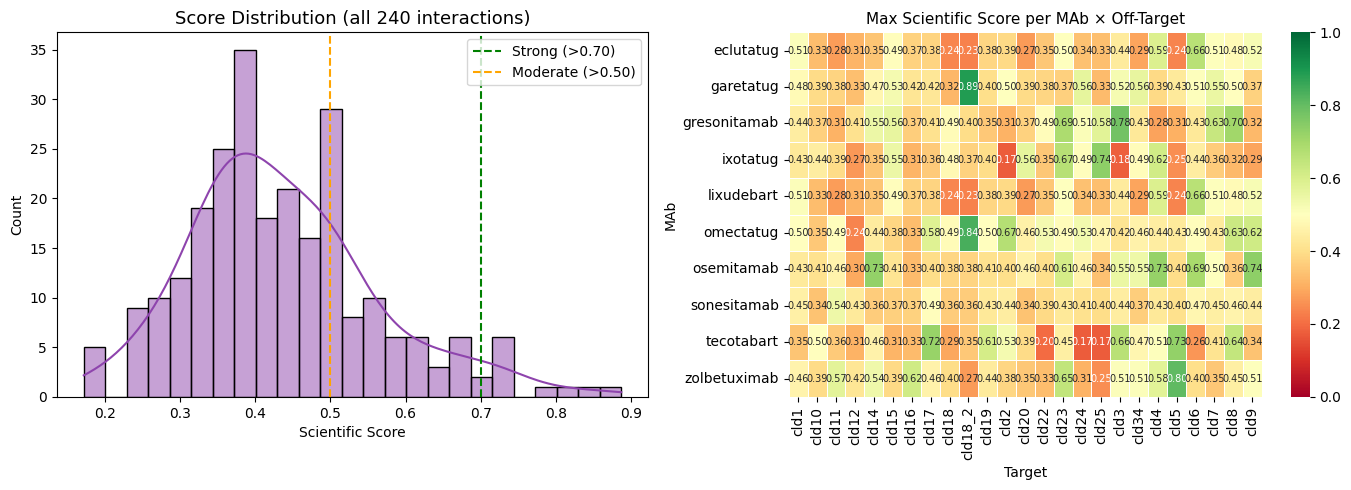

🖼️  Heatmap saved alongside CSV


In [36]:
# ─── Cell 8: Visualisation – Score Distribution ────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (A) Overall score histogram
ax = axes[0]
sns.histplot(df_sorted['Scientific_Score'], bins=25, kde=True, color='#8e44ad', ax=ax)
ax.axvline(0.70, color='green',  linestyle='--', lw=1.5, label='Strong (>0.70)')
ax.axvline(0.50, color='orange', linestyle='--', lw=1.5, label='Moderate (>0.50)')
ax.set_title('Score Distribution (all 240 interactions)', fontsize=13)
ax.set_xlabel('Scientific Score')
ax.legend()

# (B) Per-mAb mean score heatmap
ax2 = axes[1]
pivot = df_sorted.pivot_table(index='MAb', columns='Target', values='Scientific_Score', aggfunc='max')
sns.heatmap(
    pivot, ax=ax2, cmap='RdYlGn', vmin=0, vmax=1,
    linewidths=0.4, annot=True, fmt='.2f', annot_kws={'size': 7}
)
ax2.set_title('Max Scientific Score per MAb × Off-Target', fontsize=11)
ax2.tick_params(axis='x', rotation=90)
ax2.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(str(out_path.parent / 'mab_offtarget_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()
print('🖼️  Heatmap saved alongside CSV')

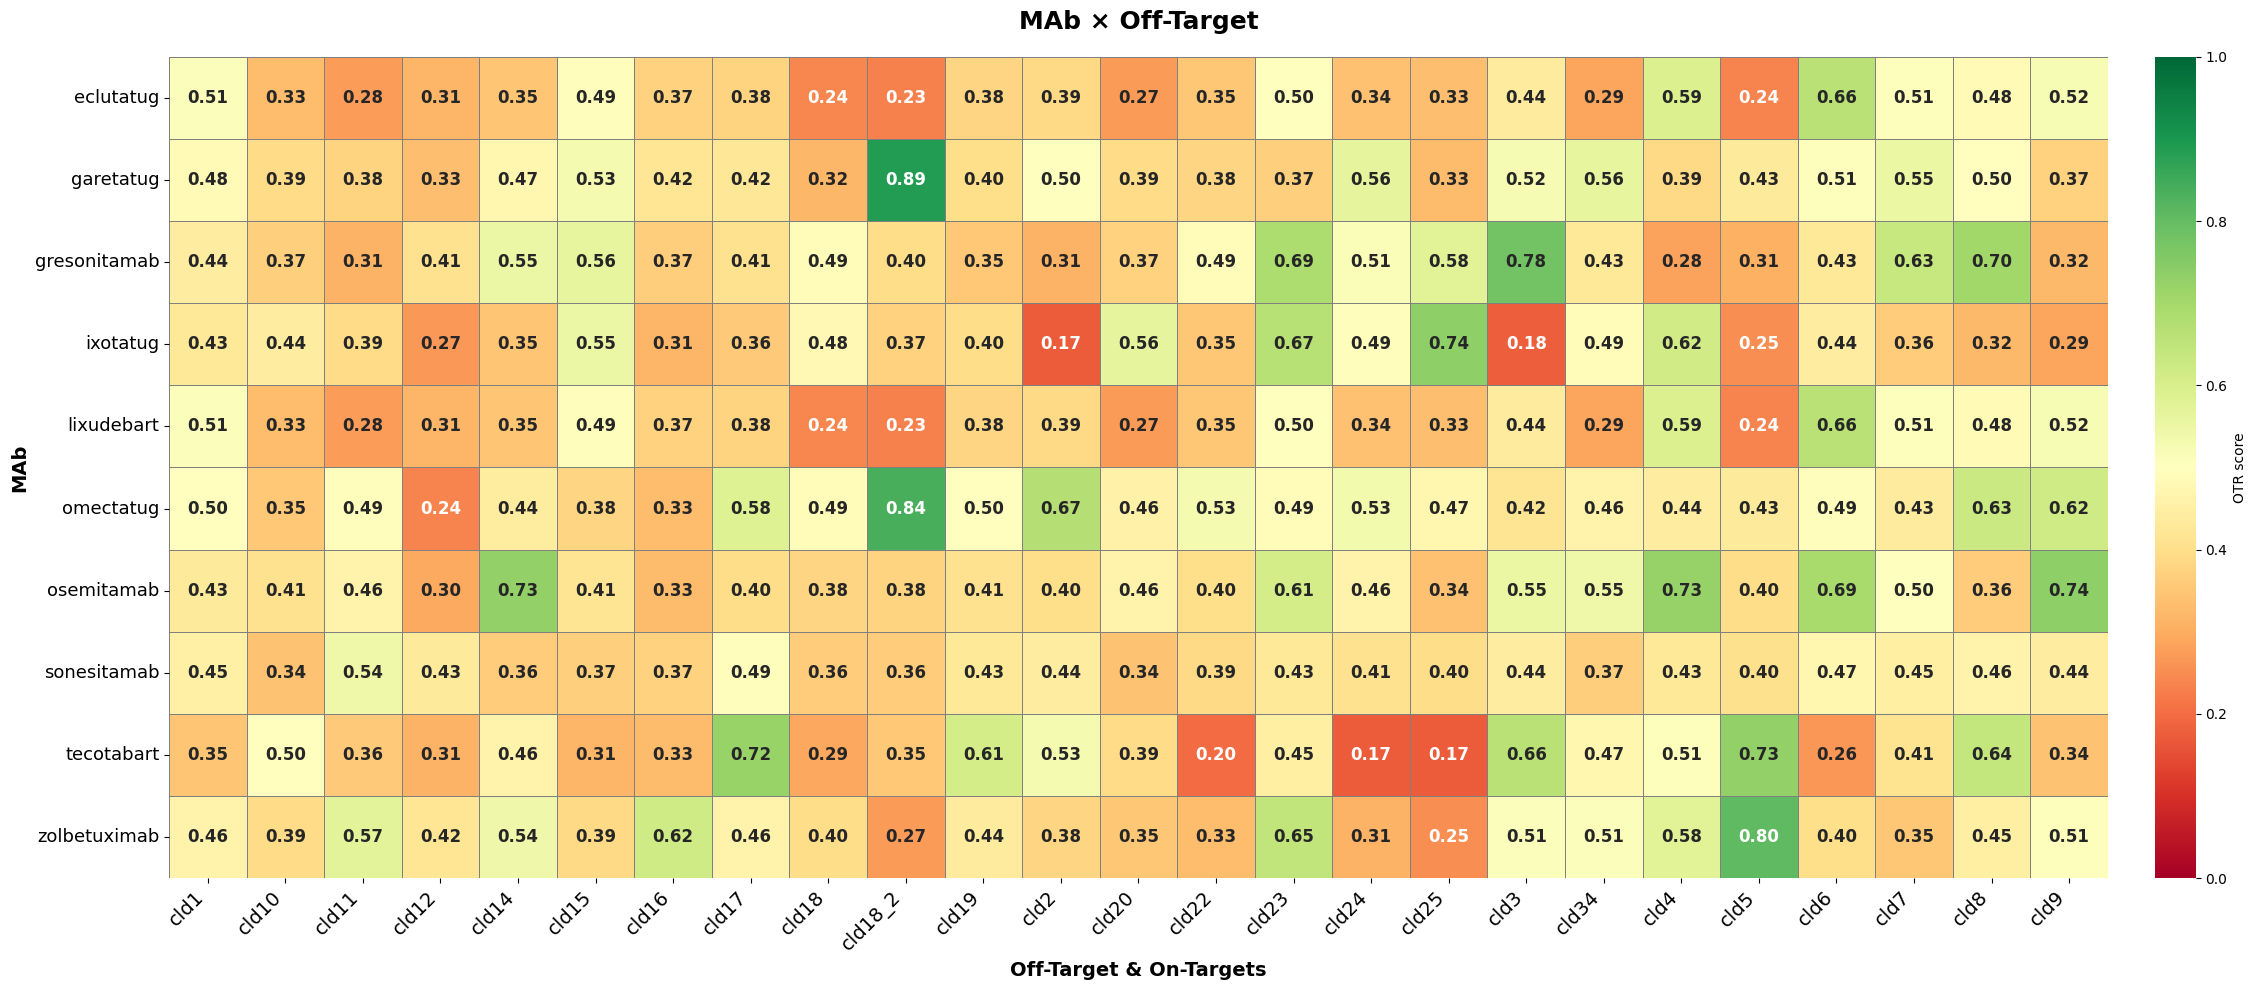

🖼️  Heatmap saved → /home/ozangocmen/RFantibody/mab_OTR/mab_offtarget_folders/results


In [43]:
# ── (B) Heatmap ────────────────────────────────────────────────────────────────
pivot = df_sorted.pivot_table(
    index='MAb', columns='Target',
    values='Scientific_Score', aggfunc='max'
)

n_mab    = pivot.shape[0]
n_target = pivot.shape[1]

fig_width  = max(14, n_target * 0.95 + 1.5)
fig_height = max(6,  n_mab    * 0.85 + 1.5)

fig_heat, ax2 = plt.subplots(figsize=(fig_width, fig_height))

sns.heatmap(
    pivot,
    ax=ax2,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0.5,
    vmin=0, vmax=1,
    linewidths=0.5,
    linecolor='gray',
    annot_kws={'size': 12, 'weight': 'bold'},
    cbar_kws={
        'label'      : 'OTR score',
        'orientation': 'vertical',
        'pad'        : 0.02,
    },
)

ax2.set_title('MAb × Off-Target',
              fontsize=18, fontweight='bold', pad=20)
ax2.set_xlabel('Off-Target & On-Targets', fontsize=14, fontweight='bold')
ax2.set_ylabel('MAb',        fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(rotation=0,              fontsize=13)

plt.tight_layout()
plt.savefig(str(out_path.parent / 'mab_offtarget_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()
print('🖼️  Heatmap saved →', out_path.parent)

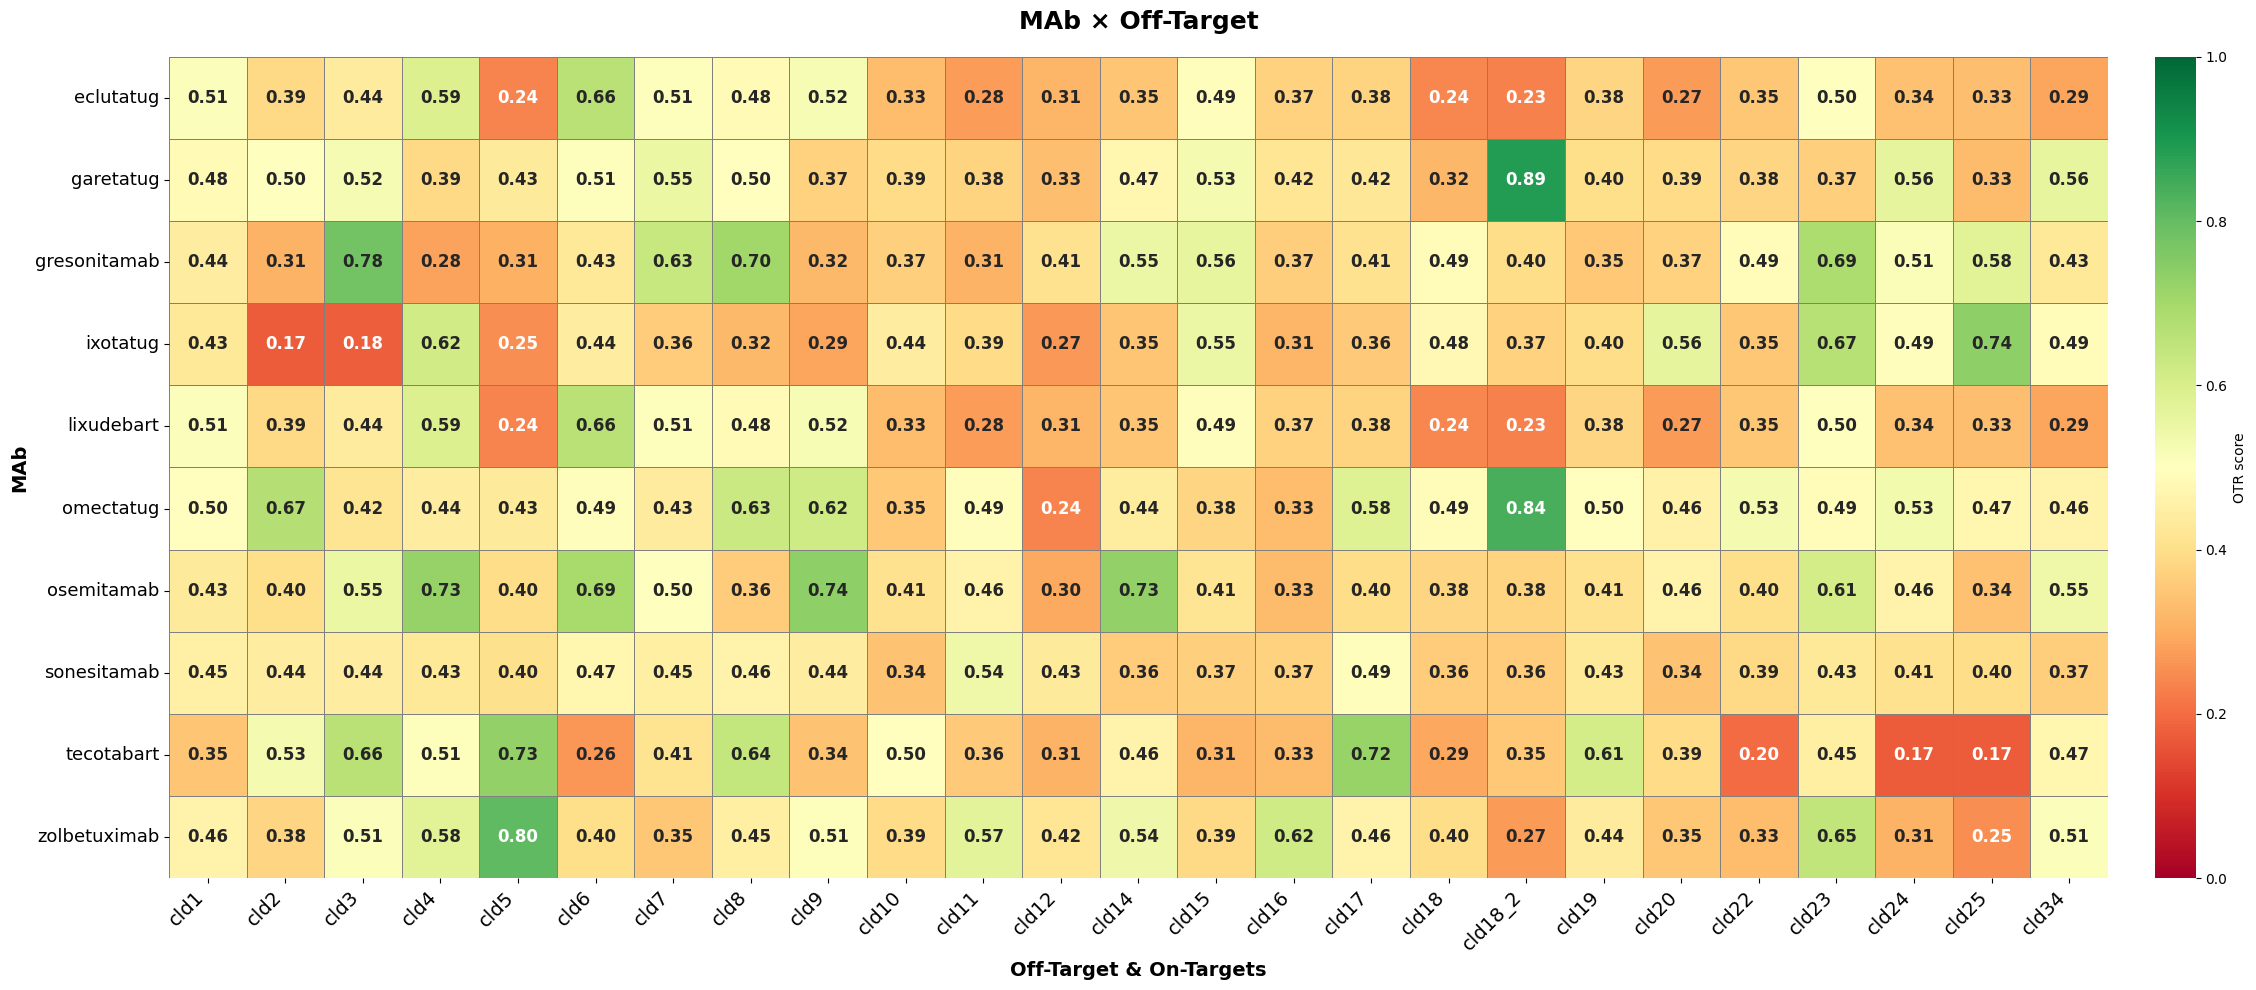

🖼️  Heatmap saved → /home/ozangocmen/RFantibody/mab_OTR/mab_offtarget_folders/results


In [44]:


# ── (B) Heatmap ────────────────────────────────────────────────────────────────
pivot = df_sorted.pivot_table(
    index='MAb', columns='Target',
    values='Scientific_Score', aggfunc='max'
)

# --- YENİ EKLENEN KISIM: Sütunları Doğal (Natural) Sıralama ---
def natural_sort_key(s):
    # Metin içindeki sayıları tespit edip gerçek sayılara (int) dönüştürür
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', str(s))]

# Sütunları bu mantığa göre sıralayıp pivot tabloyu güncelliyoruz
sorted_columns = sorted(pivot.columns, key=natural_sort_key)
pivot = pivot[sorted_columns]
# --------------------------------------------------------------

n_mab    = pivot.shape[0]
n_target = pivot.shape[1]

fig_width  = max(14, n_target * 0.95 + 1.5)
fig_height = max(6,  n_mab    * 0.85 + 1.5)

fig_heat, ax2 = plt.subplots(figsize=(fig_width, fig_height))

sns.heatmap(
    pivot,
    ax=ax2,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0.5,
    vmin=0, vmax=1,
    linewidths=0.5,
    linecolor='gray',
    annot_kws={'size': 12, 'weight': 'bold'},
    cbar_kws={
        'label'      : 'OTR score',
        'orientation': 'vertical',
        'pad'        : 0.02,
    },
)

ax2.set_title('MAb × Off-Target',
              fontsize=18, fontweight='bold', pad=20)
ax2.set_xlabel('Off-Target & On-Targets', fontsize=14, fontweight='bold')
ax2.set_ylabel('MAb',        fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(rotation=0,              fontsize=13)

plt.tight_layout()
plt.savefig(str(out_path.parent / 'mab_offtarget_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()
print('🖼️  Heatmap saved →', out_path.parent)

In [37]:
# ─── Cell 9: Summary Table per MAb ────────────────────────────────────────────

summary = (
    df_sorted
    .groupby('MAb')['Scientific_Score']
    .agg(Mean='mean', Max='max', Min='min',
         Strong_Binders=lambda s: (s >= 0.70).sum(),
         Moderate_Binders=lambda s: ((s >= 0.50) & (s < 0.70)).sum())
    .sort_values('Mean', ascending=False)
)
print('📊 Per-MAb Summary\n')
display(summary.round(3))

📊 Per-MAb Summary



,Mean,Max,Min,Strong_Binders,Moderate_Binders
MAb,,,,,
omectatug,0.489,0.839,0.237,1,6
osemitamab,0.472,0.735,0.296,3,5
gresonitamab,0.460,0.779,0.285,2,6
garetatug,0.457,0.887,0.319,1,7
zolbetuximab,0.454,0.805,0.253,1,8
tecotabart,0.421,0.727,0.172,2,5
sonesitamab,0.415,0.544,0.340,0,1
ixotatug,0.411,0.738,0.172,1,4
eclutatug,0.391,0.662,0.231,0,6


In [38]:
# ─── Cell 10: Sanity Check – Unmatched Affinities ─────────────────────────────

zero_aff = df_sorted[df_sorted['Affinity_dG'] == 0.0]

if len(zero_aff) == 0:
    print('✅ All samples matched to a Prodigy affinity value.')
else:
    print(f'⚠️  {len(zero_aff)} samples have Affinity_dG = 0 (no match found):')
    print(zero_aff[['Sample_ID', 'Scientific_Score', 'Matrix_iPTM', 'Matrix_PAE']].to_string(index=False))

✅ All samples matched to a Prodigy affinity value.


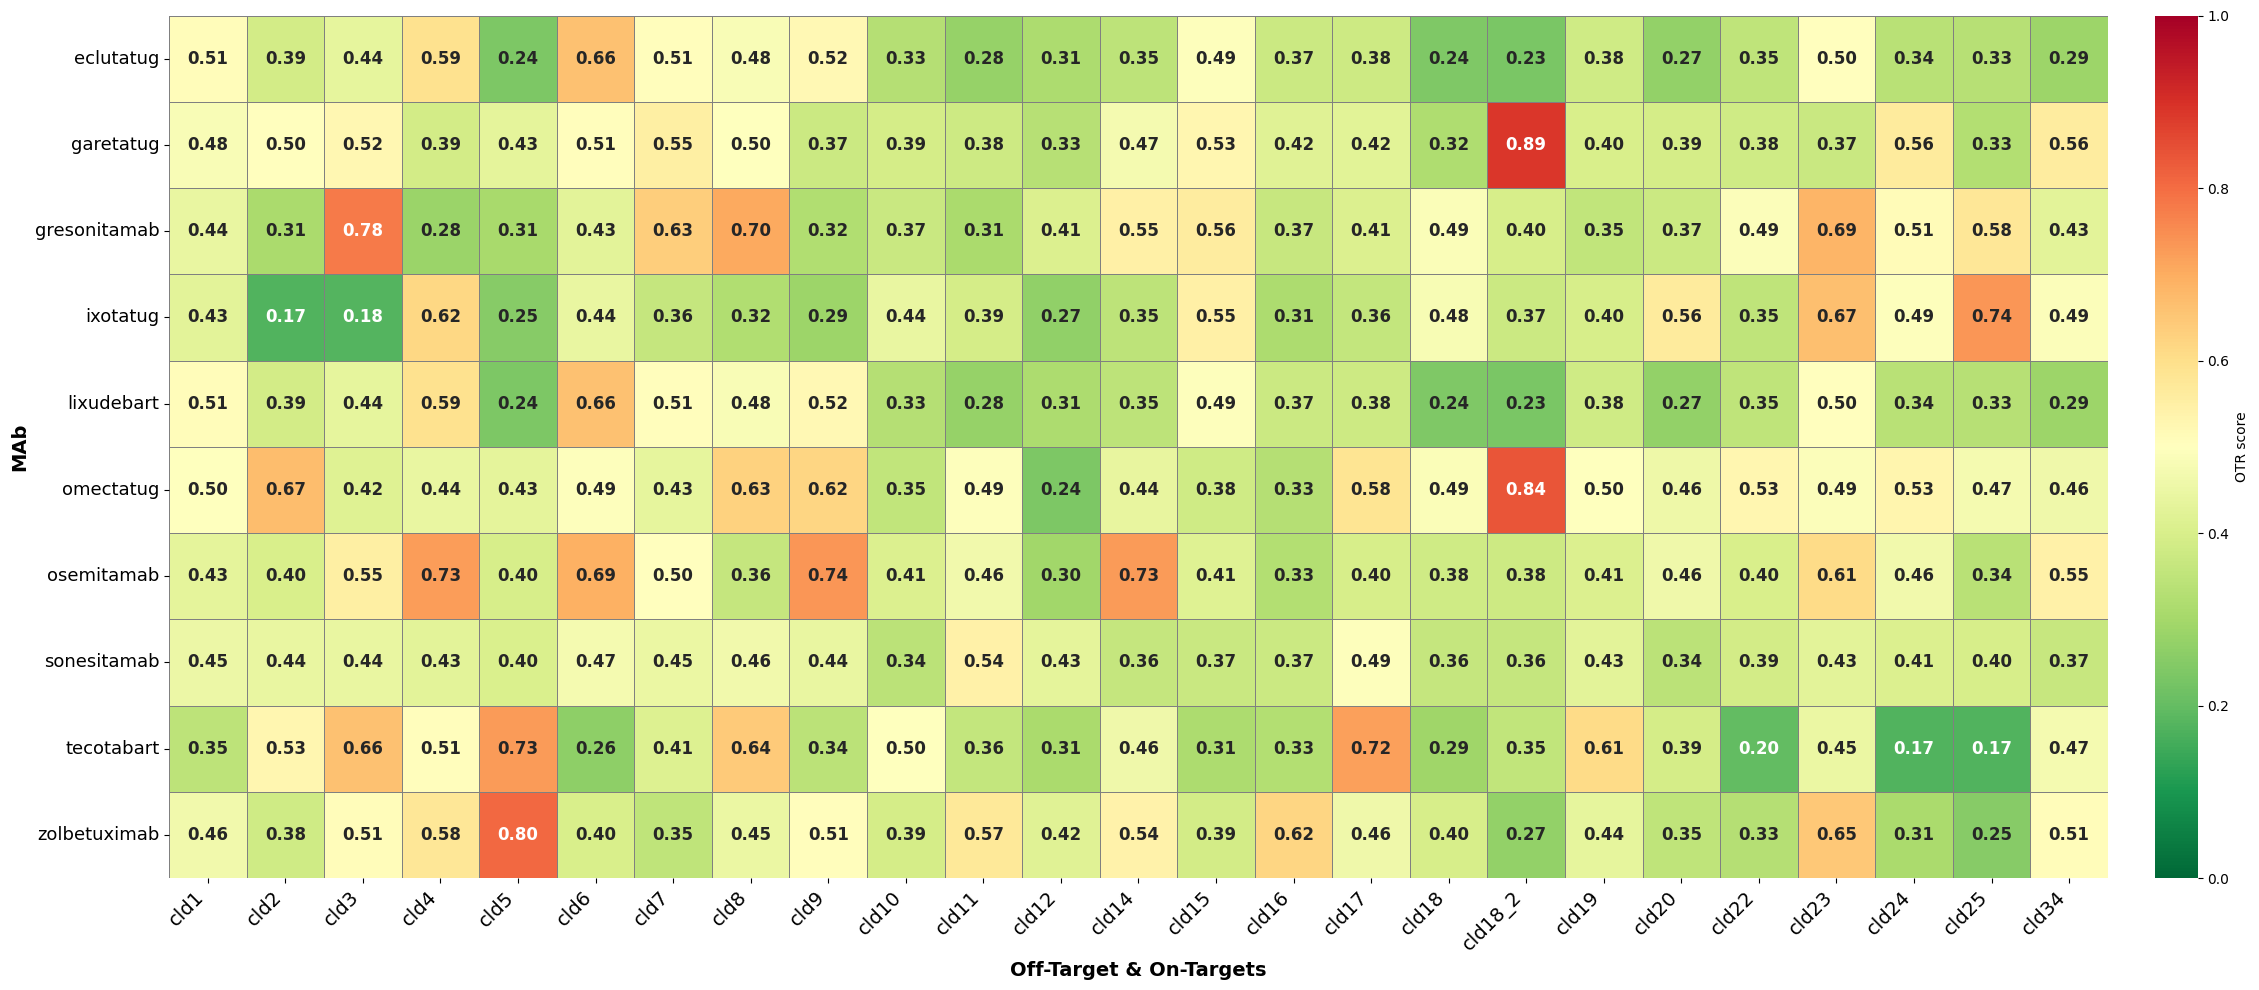

🖼️  Heatmap saved → /home/ozangocmen/RFantibody/mab_OTR/mab_offtarget_folders/results


In [ ]:


# ── (B) Heatmap ────────────────────────────────────────────────────────────────
pivot = df_sorted.pivot_table(
    index='MAb', columns='Target',
    values='Scientific_Score', aggfunc='max'
)

# --- YENİ EKLENEN KISIM: Sütunları Doğal (Natural) Sıralama ---
def natural_sort_key(s):
    # Metin içindeki sayıları tespit edip gerçek sayılara (int) dönüştürür
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', str(s))]

# Sütunları bu mantığa göre sıralayıp pivot tabloyu güncelliyoruz
sorted_columns = sorted(pivot.columns, key=natural_sort_key)
pivot = pivot[sorted_columns]
# --------------------------------------------------------------

n_mab    = pivot.shape[0]
n_target = pivot.shape[1]

fig_width  = max(14, n_target * 0.95 + 1.5)
fig_height = max(6,  n_mab    * 0.85 + 1.5)

fig_heat, ax2 = plt.subplots(figsize=(fig_width, fig_height))

sns.heatmap(
    pivot,
    ax=ax2,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    center=0.5,
    vmin=0, vmax=1,
    linewidths=0.5,
    linecolor='gray',
    annot_kws={'size': 12, 'weight': 'bold'},
    cbar_kws={
        'label'      : 'OTR score',
        'orientation': 'vertical',
        'pad'        : 0.02,
    },
)


ax2.set_xlabel('Off-Target & On-Targets', fontsize=14, fontweight='bold')
ax2.set_ylabel('MAb',        fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(rotation=0,              fontsize=13)

plt.tight_layout()
plt.savefig(str(out_path.parent / 'mab_offtarget_heatmap.pdf'), dpi=300, bbox_inches='tight')
plt.show()
print('🖼️  Heatmap saved →', out_path.parent)